<a href="https://colab.research.google.com/github/oklou2/semg-user-identification/blob/main/palm_semg_user_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
mkdir semg-auth && cd semg-auth


In [4]:
!pip install numpy scipy matplotlib pandas scikit-learn

In [5]:
!pip install pywavelets
!pip install torch torchvision


In [6]:
!python -c "import numpy, scipy, sklearn; print('OK')"

OK


In [7]:
!git clone https://github.com/sea3551/palm-sEMG-doorknob-filtered.git data

Cloning into 'data'...
remote: Enumerating objects: 295, done.
remote: Counting objects: 100% (295/295), done.
remote: Compressing objects: 100% (292/292), done.
remote: Total 295 (delta 10), reused 257 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (295/295), 6.01 MiB | 8.10 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [8]:
!ls -R data | head -40


data:
data
LICENSE
README.md

data/data:
A
B
C
D
E

data/data/A:
a (10).csv
a (11).csv
a (12).csv
a (13).csv
a (14).csv
a (15).csv
a (16).csv
a (17).csv
a (18).csv
a (19).csv
a (1).csv
a (20).csv
a (21).csv
a (22).csv
a (23).csv
a (24).csv
a (25).csv
a (26).csv
a (27).csv
a (28).csv
a (29).csv
a (2).csv
a (30).csv
a (31).csv
a (32).csv
a (33).csv
a (34).csv


In [9]:
!find data -type f | wc -l

280


In [10]:
import numpy as np, glob, os
files = sorted(glob.glob('data/**/*.csv', recursive=True))
print('파일 개수:', len(files))
print('예시 경로:', files[0])
x = np.loadtxt(files[0], delimiter=',', skiprows=1) # 형식에 맞게 변경
print('배열 모양:', x.shape) # 예: (3000, 2)
print('값 범위:', x.min(), '~', x.max())
# 피험자별 파일 수 세기
from collections import Counter
subs = [os.path.basename(os.path.dirname(f))
for f in files]
print(Counter(subs))

파일 개수: 250
예시 경로: data/data/A/a (1).csv
배열 모양: (3000, 2)
값 범위: -3.53656 ~ 4.33942
Counter({'A': 50, 'B': 50, 'C': 50, 'D': 50, 'E': 50})


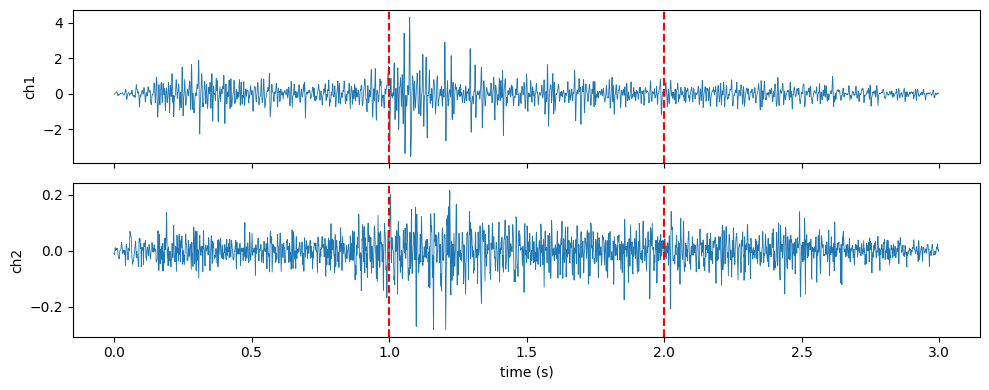

In [ ]:
import matplotlib.pyplot as plt
x = np.loadtxt(files[0], delimiter=',', skiprows=1)
if x.shape[0] < x.shape[1]: x = x.T
t = np.arange(len(x)) / 1000.0
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ch in range(2):
  ax[ch].plot(t, x[:, ch], lw=0.6)
  ax[ch].set_ylabel(f'ch{ch+1}')
for a in ax:
  a.axvline(1.0, color='r', ls='--')
  a.axvline(2.0, color='r', ls='--')
ax[1].set_xlabel('time (s)')
plt.tight_layout(); plt.savefig('signal_example.png', dpi=120)

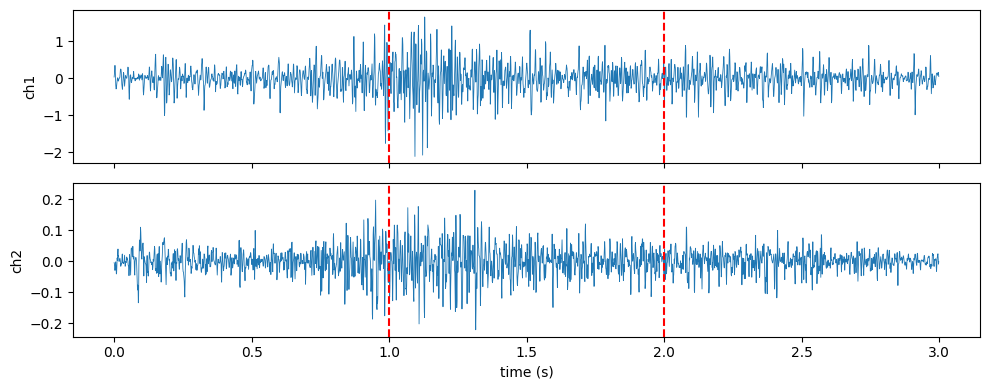

In [ ]:
import matplotlib.pyplot as plt
x = np.loadtxt(files[4], delimiter=',', skiprows=1)
if x.shape[0] < x.shape[1]: x = x.T
t = np.arange(len(x)) / 1000.0
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ch in range(2):
  ax[ch].plot(t, x[:, ch], lw=0.6)
  ax[ch].set_ylabel(f'ch{ch+1}')
for a in ax:
  a.axvline(1.0, color='r', ls='--')
  a.axvline(2.0, color='r', ls='--')
ax[1].set_xlabel('time (s)')
plt.tight_layout(); plt.savefig('signal_example.png', dpi=120)

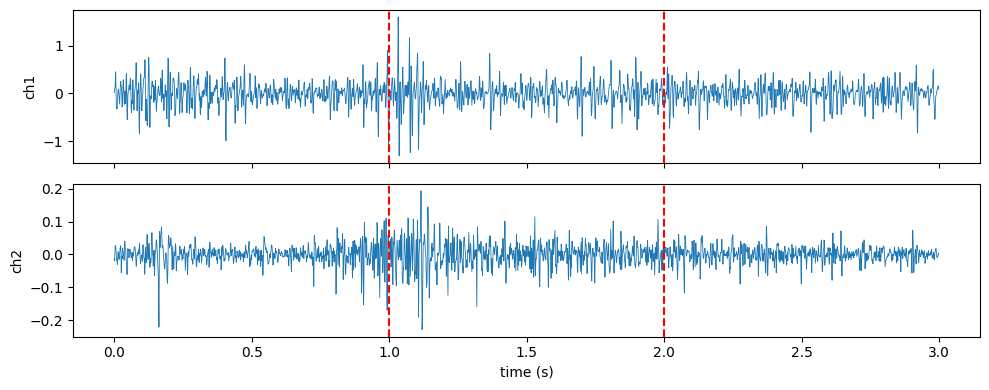

In [ ]:
import matplotlib.pyplot as plt
x = np.loadtxt(files[12], delimiter=',', skiprows=1)
if x.shape[0] < x.shape[1]: x = x.T
t = np.arange(len(x)) / 1000.0
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ch in range(2):
  ax[ch].plot(t, x[:, ch], lw=0.6)
  ax[ch].set_ylabel(f'ch{ch+1}')
for a in ax:
  a.axvline(1.0, color='r', ls='--')
  a.axvline(2.0, color='r', ls='--')
ax[1].set_xlabel('time (s)')
plt.tight_layout(); plt.savefig('signal_example.png', dpi=120)

FileNotFoundError: data/A/a (1).csv not found.

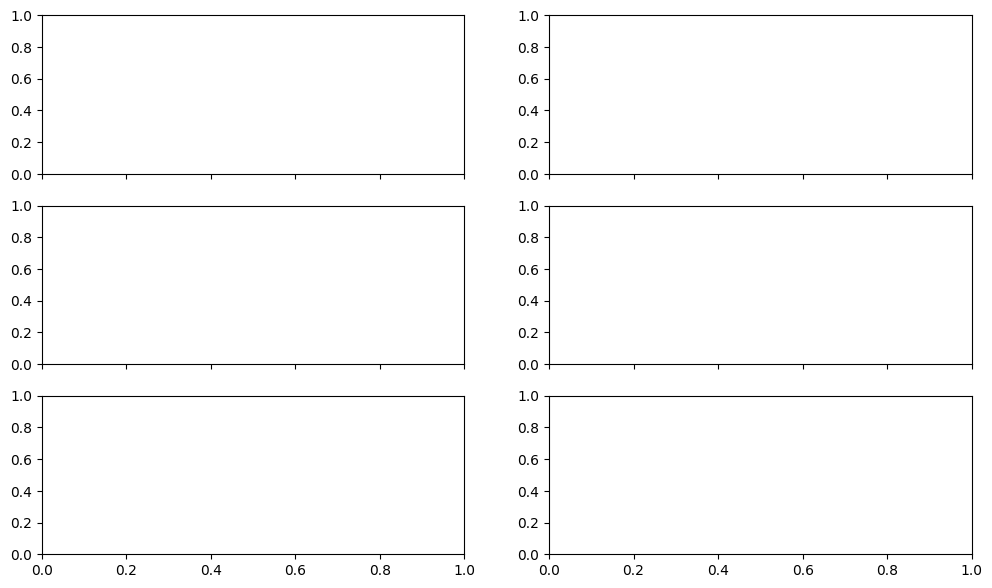

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 비교할 파일
files = {
    'A': 'data/A/a (1).csv',
    'B': 'data/B/b (1).csv',
    'C': 'data/C/c (1).csv'
}

fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=True)

for row, (subject, filepath) in enumerate(files.items()):

    # CSV 불러오기
    x = np.loadtxt(filepath, delimiter=',', skiprows=1)

    # (시간, 채널) 형태로 통일
    if x.shape[0] < x.shape[1]:
        x = x.T

    # Sampling rate = 1000 Hz
    t = np.arange(len(x)) / 1000.0

    # Channel 1, 2
    for ch in range(2):
        ax[row, ch].plot(t, x[:, ch], lw=0.6)

        # 1~2초 구간 표시
        ax[row, ch].axvline(
            1.0, color='r', ls='--'
        )
        ax[row, ch].axvline(
            2.0, color='r', ls='--'
        )

        ax[row, ch].grid(alpha=0.2)

    # 피험자 표시
    ax[row, 0].set_ylabel(f'Subject {subject}')

# 채널 제목
ax[0, 0].set_title('Channel 1')
ax[0, 1].set_title('Channel 2')

# x축
ax[-1, 0].set_xlabel('Time (s)')
ax[-1, 1].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('ABC_signal_comparison.png', dpi=150)
plt.show()


In [ ]:
%ls

data/  sample_data/  semg-auth/  signal_example.png


In [ ]:
%cd ..home

/


In [ ]:
%ls

bin@                home/               opt/                sbin.usr-is-merged/
bin.usr-is-merged/  kaggle/             proc/               srv/
boot/               lib@                python-apt/         sys/
content/            lib64@              python-apt.tar.xz*  tmp/
datalab/            lib.usr-is-merged/  root/               tools/
dev/                media/              run/                usr/
etc/                mnt/                sbin@               var/


In [ ]:
%cd /content/data

/content/data


In [ ]:
import numpy as np
import glob
import os

def extract_features(signal):
    mav = np.mean(np.abs(signal))
    rms = np.sqrt(np.mean(signal**2))
    var = np.var(signal)

    zc = np.sum(
        np.diff(np.sign(signal)) != 0
    )

    wl = np.sum(
        np.abs(np.diff(signal))
    )

    return [mav, rms, var, zc, wl]





X = []
y = []
subjects = []

for filepath in sorted(
    glob.glob('data/data/**/*.csv', recursive=True)
):

    x = np.loadtxt(
        filepath,
        delimiter=',',
        skiprows=1
    )

    if x.shape[0] < x.shape[1]:
        x = x.T

    # 0~1초
    grasp = x[0:1000]

    # 1~2초
    rotate = x[1000:2000]

    # 2~3초
    stop = x[2000:3000]

    segments = {
        'grasp': grasp,
        'rotate': rotate,
        'stop': stop
    }

    subject = os.path.basename(
        os.path.dirname(filepath)
    )

    for label, segment in segments.items():

        feature_vector = []

        # APB + ADM
        for ch in range(2):
            feature_vector.extend(
                extract_features(segment[:, ch])
            )

        X.append(feature_vector)
        y.append(label)
        subjects.append(subject)

X = np.array(X)
y = np.array(y)
subjects = np.array(subjects)

print("X:", X.shape)
print("y:", y.shape)
print("subjects:", subjects.shape)



X: (750, 10)
y: (750,)
subjects: (750,)


In [ ]:
%cd ../

/


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

results = []

for test_subject in ['A', 'B', 'C', 'D', 'E']:

    train_idx = subjects != test_subject
    test_idx = subjects == test_subject

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    model = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf')
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append(acc)

    print(
        f'Test subject {test_subject}: '
        f'{acc*100:.2f}%'
    )

print(
    f'\nLOSO 평균 정확도: '
    f'{np.mean(results)*100:.2f}%'
)


Test subject A: 36.67%
Test subject B: 32.67%
Test subject C: 50.67%
Test subject D: 28.00%
Test subject E: 41.33%

LOSO 평균 정확도: 37.87%


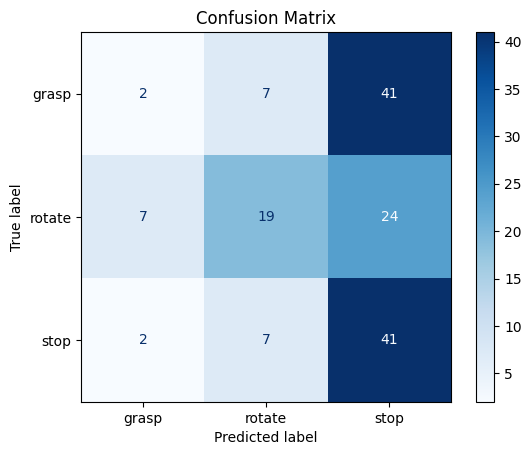

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 마지막 fold의 예시
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['grasp', 'rotate', 'stop']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['grasp', 'rotate', 'stop']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
!pip install PyWavelets

In [ ]:
import pywt
import numpy as np
import glob
import os

def dwt_features(signal, wavelet='db4', level=4):

    # DWT decomposition
    coeffs = pywt.wavedec(
        signal,
        wavelet,
        level=level
    )

    features = []

    for coeff in coeffs:

        # Energy
        energy = np.sum(coeff ** 2)

        # RMS
        rms = np.sqrt(np.mean(coeff ** 2))

        # Standard deviation
        std = np.std(coeff)

        # Shannon entropy
        power = coeff ** 2
        power = power / (np.sum(power) + 1e-12)

        entropy = -np.sum(
            power * np.log2(power + 1e-12)
        )

        features.extend([
            energy,
            rms,
            std,
            entropy
        ])

    return features

X = []
y = []
subjects = []

files = sorted(
    glob.glob(
        'data/data/**/*.csv',
        recursive=True
    )
)

print("파일 개수:", len(files))

for filepath in files:

    x = np.loadtxt(
        filepath,
        delimiter=',',
        skiprows=1
    )

    if x.shape[0] < x.shape[1]:
        x = x.T

    # 1초씩 분리
    grasp = x[0:1000]
    rotate = x[1000:2000]
    stop = x[2000:3000]

    segments = {
        'grasp': grasp,
        'rotate': rotate,
        'stop': stop
    }

    # 피험자
    subject = os.path.basename(
        os.path.dirname(filepath)
    )

    for label, segment in segments.items():

        feature_vector = []

        # APB + ADM
        for ch in range(2):

            features = dwt_features(
                segment[:, ch],
                wavelet='db4',
                level=4
            )

            feature_vector.extend(features)

        X.append(feature_vector)
        y.append(label)
        subjects.append(subject)


X = np.array(X)
y = np.array(y)
subjects = np.array(subjects)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)


파일 개수: 0
X shape: (0,)
y shape: (0,)
subjects shape: (0,)


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

results = []

for test_subject in ['A', 'B', 'C', 'D', 'E']:

    train_idx = subjects != test_subject
    test_idx = subjects == test_subject

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    model = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf')
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append(acc)

    print(
        f'Test subject {test_subject}: '
        f'{acc*100:.2f}%'
    )

print(
    f'\nLOSO 평균 정확도: '
    f'{np.mean(results)*100:.2f}%'
)


ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
import numpy as np
import glob
import os
import pywt

# ============================================
# DWT 특징 추출 함수
# ============================================

def extract_dwt_features(signal, wavelet='db4', level=4):

    # DWT
    coeffs = pywt.wavedec(
        signal,
        wavelet,
        level=level
    )

    features = []

    for coeff in coeffs:

        # Energy
        energy = np.sum(coeff ** 2)

        # RMS
        rms = np.sqrt(
            np.mean(coeff ** 2)
        )

        # Standard deviation
        std = np.std(coeff)

        # Entropy
        power = coeff ** 2
        power = power / (
            np.sum(power) + 1e-12
        )

        entropy = -np.sum(
            power * np.log2(power + 1e-12)
        )

        features.extend([
            energy,
            rms,
            std,
            entropy
        ])

    return features


# ============================================
# 데이터 불러오기
# ============================================

files = sorted(
    glob.glob(
        'data/data/**/*.csv',
        recursive=True
    )
)

print("파일 개수:", len(files))


X = []
y = []
subjects = []


# ============================================
# 각 CSV 처리
# ============================================

for filepath in files:

    x = np.loadtxt(
        filepath,
        delimiter=',',
        skiprows=1
    )

    # (시간, 채널) 형태로 통일
    if x.shape[0] < x.shape[1]:
        x = x.T

    # 확인
    if x.shape != (3000, 2):
        print(
            "주의:",
            filepath,
            x.shape
        )

    # ----------------------------------------
    # 3개 동작 구간
    # ----------------------------------------

    grasp = x[0:1000]
    rotate = x[1000:2000]
    stop = x[2000:3000]

    segments = {
        'grasp': grasp,
        'rotate': rotate,
        'stop': stop
    }

    # ----------------------------------------
    # 피험자
    # ----------------------------------------

    subject = os.path.basename(
        os.path.dirname(filepath)
    )

    # ----------------------------------------
    # 특징 추출
    # ----------------------------------------

    for label, segment in segments.items():

        feature_vector = []

        # Channel 1 = APB
        # Channel 2 = ADM

        for ch in range(2):

            features = extract_dwt_features(
                segment[:, ch],
                wavelet='db4',
                level=4
            )

            feature_vector.extend(features)

        X.append(feature_vector)
        y.append(label)
        subjects.append(subject)


# ============================================
# numpy array
# ============================================

X = np.array(X)
y = np.array(y)
subjects = np.array(subjects)


print("\n===== 데이터 확인 =====")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)

print("\nLabel distribution:")
print(
    np.unique(
        y,
        return_counts=True
    )
)

print("\nSubject distribution:")
print(
    np.unique(
        subjects,
        return_counts=True
    )
)


파일 개수: 0

===== 데이터 확인 =====
X shape: (0,)
y shape: (0,)
subjects shape: (0,)

Label distribution:
(array([], dtype=float64), array([], dtype=int64))

Subject distribution:
(array([], dtype=float64), array([], dtype=int64))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================
# Label encoding
# ============================================

label_map = {
    'grasp': 0,
    'rotate': 1,
    'stop': 2
}

y_num = np.array([
    label_map[label]
    for label in y
])


# ============================================
# Train / Test split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_num,
    test_size=0.2,
    random_state=42,
    stratify=y_num
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ============================================
# DNN
# ============================================

model = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        3,
        activation='softmax'
    )
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,283 (20.64 KB)

 Trainable params: 5,283 (20.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


history = model.fit(

    X_train,
    y_train,

    epochs=100,

    batch_size=16,

    validation_split=0.2,

    callbacks=[early_stopping],

    verbose=1
)


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3625 - loss: 1.1122 - val_accuracy: 0.4917 - val_loss: 1.0224
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4354 - loss: 1.0777 - val_accuracy: 0.5167 - val_loss: 1.0060
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4500 - loss: 1.0244 - val_accuracy: 0.5417 - val_loss: 0.9664
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5396 - loss: 0.9776 - val_accuracy: 0.5500 - val_loss: 0.9514
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5542 - loss: 0.9192 - val_accuracy: 0.6083 - val_loss: 0.9119
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5542 - loss: 0.9222 - val_accuracy: 0.5500 - val_loss: 0.9178
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.8681 - val_accuracy: 0.6083 - val_loss: 0.8771
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5979 - loss: 0.9004 - val_accuracy: 0.5750 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


AttributeError: 'DenseNet' object has no attribute 'evaluate'

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt # Ensure plt is imported for plt.title and plt.show

# Define label_map to convert string predictions to numerical labels
label_map = {
    'grasp': 0,
    'rotate': 1,
    'stop': 2
}

# Convert y_pred (which is currently strings) to numerical labels
y_pred_numerical = np.array([label_map[label] for label in y_pred])

# 마지막 fold의 예시
cm = confusion_matrix(
    y_test, # y_test is already numerical (0, 1, 2)
    y_pred_numerical, # Use numerical predictions
    labels=[0, 1, 2] # Specify numerical labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['grasp', 'rotate', 'stop'] # Display string labels
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'y_pred' is not defined

In [ ]:
import numpy as np
import glob
import os
import pywt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# =========================================================
# 1. DWT 특징 추출
# =========================================================

def extract_dwt_features(signal, wavelet='db4', level=4):

    coeffs = pywt.wavedec(
        signal,
        wavelet=wavelet,
        level=level
    )

    features = []

    for coeff in coeffs:

        # Energy
        energy = np.sum(coeff ** 2)

        # RMS
        rms = np.sqrt(
            np.mean(coeff ** 2)
        )

        # Standard deviation
        std = np.std(coeff)

        # Shannon entropy
        power = coeff ** 2
        power = power / (
            np.sum(power) + 1e-12
        )

        entropy = -np.sum(
            power * np.log2(
                power + 1e-12
            )
        )

        features.extend([
            energy,
            rms,
            std,
            entropy
        ])

    return features


# =========================================================
# 2. CSV 파일 불러오기
# =========================================================

files = sorted(
    glob.glob(
        'data/data/**/*.csv',
        recursive=True
    )
)

print("전체 CSV 파일 수:", len(files))


# =========================================================
# 3. 사용자별 파일 분류
#
# A의 50 trial
# B의 50 trial
# ...
# =========================================================

subject_files = {}

for filepath in files:

    subject = os.path.basename(
        os.path.dirname(filepath)
    )

    if subject not in subject_files:
        subject_files[subject] = []

    subject_files[subject].append(filepath)


print("\n===== 사용자별 trial 수 =====")

for subject, file_list in subject_files.items():
    print(
        subject,
        len(file_list)
    )


# =========================================================
# 4. 사용자별로 80 : 20 split
#
# 여기서 중요:
# 특징을 만든 뒤 split하지 않고
# CSV(trial) 자체를 먼저 split한다.
#
# A: 40 train / 10 test
# B: 40 train / 10 test
# ...
# =========================================================

train_files = []
test_files = []

for subject, file_list in subject_files.items():

    subject_train, subject_test = train_test_split(
        file_list,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    train_files.extend(subject_train)
    test_files.extend(subject_test)


print("\n===== Split 결과 =====")
print("Train trial 수:", len(train_files))
print("Test trial 수 :", len(test_files))


# =========================================================
# 5. 특징 데이터 생성 함수
#
# 핵심:
# y = grasp/rotate/stop이 아니라
# y = A/B/C/D/E
# =========================================================

def build_dataset(file_list):

    X = []
    y = []

    # 어떤 trial에서 왔는지 확인용
    trial_ids = []

    # 어느 동작 구간인지 확인용
    phases = []

    for filepath in file_list:

        x = np.loadtxt(
            filepath,
            delimiter=',',
            skiprows=1
        )

        # (시간, 채널) 형태로 통일
        if x.shape[0] < x.shape[1]:
            x = x.T

        if x.shape != (3000, 2):
            print(
                "주의:",
                filepath,
                x.shape
            )
            continue

        # -----------------------------
        # 사용자 = 정답 label
        # -----------------------------

        subject = os.path.basename(
            os.path.dirname(filepath)
        )

        # -----------------------------
        # 3초 trial을
        # grasp / rotate / stop으로 분리
        # -----------------------------

        segments = {
            'grasp': x[0:1000],
            'rotate': x[1000:2000],
            'stop': x[2000:3000]
        }

        for phase, segment in segments.items():

            feature_vector = []

            # Channel 1 = APB
            # Channel 2 = ADM

            for ch in range(2):

                features = extract_dwt_features(
                    segment[:, ch],
                    wavelet='db4',
                    level=4
                )

                feature_vector.extend(
                    features
                )

            X.append(
                feature_vector
            )

            # ============================
            # 가장 중요한 부분
            # ============================

            # 기존 코드:
            #
            # y.append(phase)
            #
            # → grasp/rotate/stop 분류
            #
            # 변경:
            #
            # y.append(subject)
            #
            # → A/B/C/D/E 사용자 분류

            y.append(subject)

            trial_ids.append(filepath)
            phases.append(phase)

    return (
        np.array(X),
        np.array(y),
        np.array(trial_ids),
        np.array(phases)
    )


# =========================================================
# 6. Train / Test 특징 생성
# =========================================================

X_train, y_train, train_trials, train_phases = (
    build_dataset(train_files)
)

X_test, y_test, test_trials, test_phases = (
    build_dataset(test_files)
)


print("\n===== 최종 데이터 =====")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_test :",
    X_test.shape
)

print(
    "y_test :",
    y_test.shape
)


print("\nTrain 사용자 분포:")
print(
    np.unique(
        y_train,
        return_counts=True
    )
)

print("\nTest 사용자 분포:")
print(
    np.unique(
        y_test,
        return_counts=True
    )
)


# =========================================================
# 7. Data leakage 확인
#
# 동일한 CSV trial이
# train과 test에 동시에 존재하는지 검사
# =========================================================

train_trial_set = set(
    train_trials
)

test_trial_set = set(
    test_trials
)

overlap = (
    train_trial_set
    & test_trial_set
)

print(
    "\nTrain/Test 중복 trial 수:",
    len(overlap)
)

if len(overlap) == 0:
    print(
        "OK: 동일 trial이 "
        "Train/Test에 동시에 들어가지 않았습니다."
    )
else:
    print(
        "WARNING: Data leakage 발생"
    )


# =========================================================
# 8. SVM 학습
#
# 분류 대상:
# A / B / C / D / E
# =========================================================

model = make_pipeline(

    StandardScaler(),

    SVC(
        kernel='rbf'
    )
)


model.fit(
    X_train,
    y_train
)


# =========================================================
# 9. 테스트
# =========================================================

y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "\n=============================="
)

print(
    f"User Identification Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print(
    "=============================="
)


# =========================================================
# 10. 사용자별 성능
# =========================================================

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


# =========================================================
# 11. Confusion Matrix
# =========================================================

labels = sorted(
    np.unique(y_test)
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

print(
    "\nLabels:",
    labels
)

print(
    "\nConfusion Matrix:"
)

print(cm)

전체 CSV 파일 수: 0

===== 사용자별 trial 수 =====

===== Split 결과 =====
Train trial 수: 0
Test trial 수 : 0

===== 최종 데이터 =====
X_train: (0,)
y_train: (0,)
X_test : (0,)
y_test : (0,)

Train 사용자 분포:
(array([], dtype=float64), array([], dtype=int64))

Test 사용자 분포:
(array([], dtype=float64), array([], dtype=int64))

Train/Test 중복 trial 수: 0
OK: 동일 trial이 Train/Test에 동시에 들어가지 않았습니다.


ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
import numpy as np
import glob
import os
import pywt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# ==============================
# DWT 특징 추출
# ==============================

def dwt_features(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)

    features = []

    for coeff in coeffs:
        energy = np.sum(coeff ** 2)
        rms = np.sqrt(np.mean(coeff ** 2))
        std = np.std(coeff)

        power = coeff ** 2
        power = power / (np.sum(power) + 1e-12)
        entropy = -np.sum(power * np.log2(power + 1e-12))

        features.extend([
            energy,
            rms,
            std,
            entropy
        ])

    return features


# ==============================
# 데이터 불러오기
#
# 1 CSV = 1 trial = 1 sample
# 3초 전체를 사용
# ==============================

X = []
y = []

files = sorted(
    glob.glob(
        'data/data/**/*.csv',
        recursive=True
    )
)

for filepath in files:

    x = np.loadtxt(
        filepath,
        delimiter=',',
        skiprows=1
    )

    if x.shape[0] < x.shape[1]:
        x = x.T

    # 사용자 A/B/C/D/E
    subject = os.path.basename(
        os.path.dirname(filepath)
    )

    feature_vector = []

    # 2채널 각각 3초 전체에 DWT 적용
    for ch in range(2):

        features = dwt_features(
            x[:, ch],
            wavelet='db4',
            level=4
        )

        feature_vector.extend(features)

    X.append(feature_vector)
    y.append(subject)


X = np.array(X)
y = np.array(y)

print("전체 데이터:", X.shape)


# ==============================
# Train / Test = 8 : 2
#
# stratify=y:
# A~E가 각각 동일 비율로 들어가도록 분할
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==============================
# SVM
# ==============================

model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)

model.fit(
    X_train,
    y_train
)


# ==============================
# 예측
# ==============================

y_pred = model.predict(
    X_test
)


# ==============================
# 피험자별 정확도
# ==============================

print("\n===== 피험자별 정확도 =====")

subjects = sorted(
    np.unique(y_test)
)

for subject in subjects:

    idx = (
        y_test == subject
    )

    acc = accuracy_score(
        y_test[idx],
        y_pred[idx]
    )

    print(
        f"{subject}: "
        f"{acc * 100:.2f}%"
    )


# ==============================
# 전체 모델 정확도
# ==============================

overall_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n=========================")
print(
    f"전체 모델 정확도: "
    f"{overall_accuracy * 100:.2f}%"
)
print("=========================")

전체 데이터: (250, 40)

===== 피험자별 정확도 =====
A: 70.00%
B: 100.00%
C: 100.00%
D: 100.00%
E: 90.00%

전체 모델 정확도: 92.00%


In [ ]:
import numpy as np
import glob
import os
import pywt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# ==============================
# CWT 특징 추출
# ==============================

def cwt_features(signal, wavelet='morl', num_scales=32):

    scales = np.arange(1, num_scales + 1)

    coeffs, _ = pywt.cwt(
        signal,
        scales,
        wavelet
    )

    coeffs = np.abs(coeffs)

    features = []

    # 각 scale별 특징 추출
    for coeff in coeffs:

        mean = np.mean(coeff)
        std = np.std(coeff)
        energy = np.sum(coeff ** 2)

        power = coeff ** 2
        power = power / (np.sum(power) + 1e-12)

        entropy = -np.sum(
            power * np.log2(power + 1e-12)
        )

        features.extend([
            mean,
            std,
            energy,
            entropy
        ])

    return features


# ==============================
# 데이터 불러오기
#
# 1 CSV = 1 trial = 1 sample
# ==============================

X = []
y = []

files = sorted(
    glob.glob(
        'data/data/**/*.csv',
        recursive=True
    )
)

for filepath in files:

    x = np.loadtxt(
        filepath,
        delimiter=',',
        skiprows=1
    )

    if x.shape[0] < x.shape[1]:
        x = x.T

    subject = os.path.basename(
        os.path.dirname(filepath)
    )

    feature_vector = []

    # 2채널 각각 CWT 특징 추출
    for ch in range(2):

        features = cwt_features(
            x[:, ch],
            wavelet='morl',
            num_scales=32
        )

        feature_vector.extend(features)

    X.append(feature_vector)
    y.append(subject)


X = np.array(X)
y = np.array(y)

print("전체 데이터:", X.shape)


# ==============================
# Train / Test = 8 : 2
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==============================
# 표준화
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==============================
# DNN
#
# 256 → 128 → 64 → 32 → 5
# ==============================

model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train,
    y_train
)


# ==============================
# 예측
# ==============================

y_pred = model.predict(
    X_test
)


# ==============================
# 피험자별 정확도
# ==============================

print("\n===== 피험자별 정확도 =====")

subjects = sorted(
    np.unique(y_test)
)

for subject in subjects:

    idx = (
        y_test == subject
    )

    acc = accuracy_score(
        y_test[idx],
        y_pred[idx]
    )

    print(
        f"{subject}: "
        f"{acc * 100:.2f}%"
    )


# ==============================
# 전체 모델 정확도
# ==============================

overall_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n=========================")
print(
    f"전체 모델 정확도: "
    f"{overall_accuracy * 100:.2f}%"
)
print("=========================")

전체 데이터: (0,)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
import glob

files = sorted(
    glob.glob('data/**/*.csv', recursive=True)
)

print("찾은 파일 수:", len(files))
print(files[:10])
print("찾은 CSV 수:", len(files))

if len(files) == 0:
    raise ValueError("CSV 파일을 찾지 못했습니다. 데이터 경로를 확인하세요.")

print(files[:5])

찾은 파일 수: 250
['data/data/A/a (1).csv', 'data/data/A/a (10).csv', 'data/data/A/a (11).csv', 'data/data/A/a (12).csv', 'data/data/A/a (13).csv', 'data/data/A/a (14).csv', 'data/data/A/a (15).csv', 'data/data/A/a (16).csv', 'data/data/A/a (17).csv', 'data/data/A/a (18).csv']
찾은 CSV 수: 250
['data/data/A/a (1).csv', 'data/data/A/a (10).csv', 'data/data/A/a (11).csv', 'data/data/A/a (12).csv', 'data/data/A/a (13).csv']


In [ ]:
%ls

data/  sample_data/  semg-auth/  signal_example.png


In [ ]:
%cd content/

/content


In [ ]:
from scipy.signal import butter, iirnotch, filtfilt
FS = 1000
def preprocess(x, fs=FS):
# 1) 60 Hz 전원선잡음제거
  bn, an = iirnotch(60, 30, fs)
  x = filtfilt(bn, an, x, axis=0)
# 2) 20~499 Hz 대역만통과(4차)
  b, a = butter(4, [20/(fs/2), 499/(fs/2)], btype='band')
  return filtfilt(b, a, x, axis=0)
xf = preprocess(x)
print('전:', x.std(), ' 후:', xf.std())

전: 0.06080678313300833  후: 0.05992463411909529


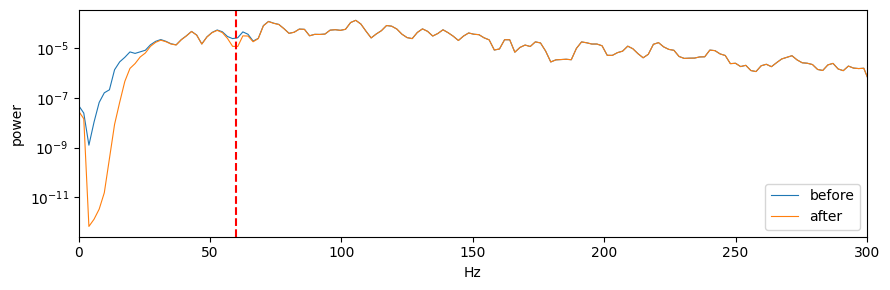

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import welch
f0, P0 = welch(x[:, 0], fs=FS, nperseg=512)
f1, P1 = welch(xf[:, 0], fs=FS, nperseg=512)
plt.figure(figsize=(9, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--')
plt.xlim(0, 300); plt.legend()
plt.xlabel('Hz'); plt.ylabel('power')
plt.tight_layout(); plt.savefig('filter_check.png', dpi=120)

In [ ]:
WIN, HOP = 300, 150 # 샘플단위(1000Hz -> 300ms, 150ms)
def make_windows(x, win=WIN, hop=HOP):
  """x: (시간, 채널) -> (윈도우수, win, 채널)"""
  n = (len(x) -win) // hop + 1
  return np.stack([x[i*hop : i*hop+win] for i in range(n)])
w = make_windows(xf)
print('윈도우배열모양:', w.shape) # (19, 300, 2)

윈도우배열모양: (19, 300, 2)


In [ ]:
def minmax(w, eps=1e-8):
  """w: (윈도우수, 시간, 채널)"""
  mn = w.min(axis=(1, 2), keepdims=True)
  mx = w.max(axis=(1, 2), keepdims=True)
  return (w -mn) / (mx -mn + eps)
wn = minmax(w)
print('값범위:', wn.min(), '~', wn.max())

값범위: 0.0 ~ 0.9999999941614188


In [ ]:
import pywt
SCALES = np.arange(1, 33) # 스케일32개
def to_cwt(one_window, wavelet='morl'):
  """(300, 2) -> (3, 32, 300)"""
  maps = []
  for ch in range(one_window.shape[1]):
    coef, _ = pywt.cwt(one_window[:, ch], SCALES, wavelet)
    maps.append(np.abs(coef)) # (32, 300)
  maps.append((maps[0] + maps[1]) / 2) # 3번째채널
  return np.stack(maps).astype(np.float32)
t = to_cwt(wn[0])
print('입력텐서모양:', t.shape) # (3, 32, 300)

입력텐서모양: (3, 32, 300)


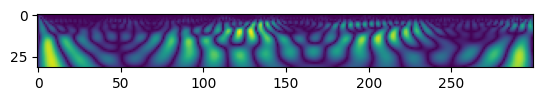

In [ ]:
plt.imshow(t[0])

In [ ]:
from sklearn.model_selection import train_test_split
# 1) 시행단위로먼저분할← 순서가핵심
tr_files, te_files = train_test_split(
  files, test_size=0.2, stratify=labels,
  random_state=42)
# 2) 각집합안에서만윈도우생성
def build(flist):
  X, y = [], []
  for f in flist:
    sig = preprocess(load(f))
    for w in minmax(make_windows(sig)):
      X.append(to_cwt(w)); y.append(label_of(f))
  return np.stack(X), np.array(y)
Xtr, ytr = build(tr_files)

NameError: name 'files' is not defined

In [ ]:
import os

labels = [
    os.path.basename(os.path.dirname(f))
    for f in files
]

print(labels[:10])
print("라벨 개수:", len(labels))

['', '', '']
라벨 개수: 3


In [ ]:
from sklearn.model_selection import train_test_split

tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("train:", len(tr_files))
print("test:", len(te_files))

KeyError: np.int64(1)

In [ ]:
from collections import Counter

print(Counter(labels))

NameError: name 'labels' is not defined

In [ ]:
tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [ ]:
import numpy as np
import os

def load(f):
    x = np.loadtxt(
        f,
        delimiter=',',
        skiprows=1
    )

    # (채널, 시간) 형태면 (시간, 채널)로 변환
    if x.shape[0] < x.shape[1]:
        x = x.T

    return x

In [ ]:
def label_of(f):
    return os.path.basename(os.path.dirname(f))

In [ ]:
import numpy as np
import os

def load(f):
    x = np.loadtxt(
        f,
        delimiter=',',
        skiprows=1
    )

    if x.shape[0] < x.shape[1]:
        x = x.T

    return x


def label_of(f):
    return os.path.basename(os.path.dirname(f))

In [ ]:
from sklearn.model_selection import train_test_split

tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

def build(flist):
    X, y = [], []

    for f in flist:
        sig = preprocess(load(f))

        for w in minmax(make_windows(sig)):
            X.append(to_cwt(w))
            y.append(label_of(f))

    return np.stack(X), np.array(y)

Xtr, ytr = build(tr_files)

In [ ]:
import torch, torch.nn as nn
from torchvision.models import densenet161
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
model = densenet161(weights=None) # 사전학습미사용
model.classifier = nn.Linear(2208, 5) # 5명분류
model = model.to(dev)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
for epoch in range(45):
  model.train(); tot = 0
  for xb, yb in train_loader: # batch=16
    xb, yb = xb.to(dev), yb.to(dev)
    loss = crit(model(xb), yb)
    opt.zero_grad(); loss.backward(); opt.step()
    tot += loss.item()
  print(epoch+1, tot/len(train_loader))

KeyboardInterrupt: 

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# A~E 문자열 라벨을 0~4 숫자로 변환
label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = [label_map[y] for y in ytr]

# numpy -> torch tensor
Xtr_tensor = torch.tensor(Xtr, dtype=torch.float32)
ytr_tensor = torch.tensor(ytr_num, dtype=torch.long)

# dataset / dataloader 생성
train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print("Xtr:", Xtr_tensor.shape)
print("ytr:", ytr_tensor.shape)
print("batch 수:", len(train_loader))

NameError: name 'ytr' is not defined

In [ ]:
import torch.nn as nn
from torchvision.models import densenet161

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

model = densenet161(weights=None)
model.classifier = nn.Linear(2208, 5)
model = model.to(dev)

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()

for epoch in range(45):
    model.train()
    tot = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(dev), yb.to(dev)

        loss = crit(model(xb), yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tot += loss.item()

    print(epoch + 1, tot / len(train_loader))

1 1.0195739684986467
2 0.6806008193422767


KeyboardInterrupt: 

In [ ]:
print(dev)

NameError: name 'dev' is not defined

In [ ]:
print(torch.cuda.is_available())
print(dev)

NameError: name 'torch' is not defined

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU 없음")

True
Tesla T4


In [ ]:
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print(dev)

cuda


In [ ]:
# 1. train/test 파일 분할
from sklearn.model_selection import train_test_split

tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

NameError: name 'labels' is not defined

사용 장치: cuda
GPU: Tesla T4
전체 파일 수: 250
라벨 수: 250


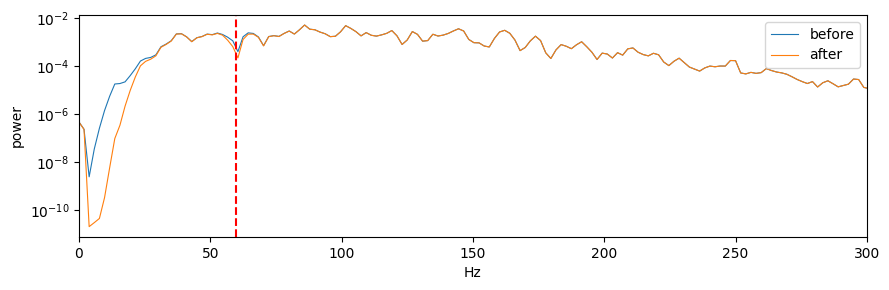

윈도우 배열 모양: (19, 300, 2)
정규화 범위: 0.0 ~ 0.9999999987119951
CWT 텐서 모양: (3, 32, 300)


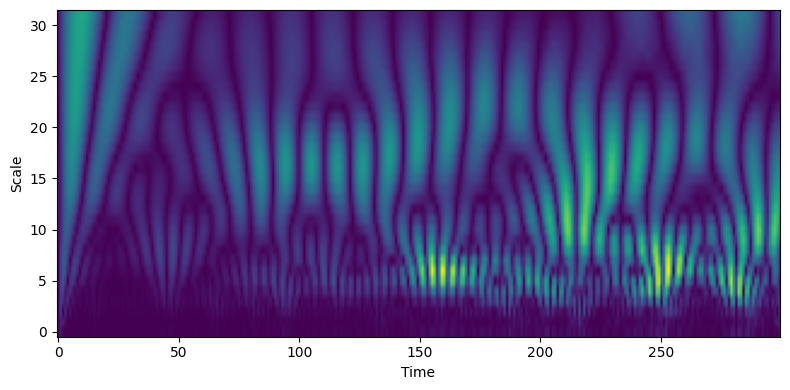

train trial: 200
test trial: 50

Train 데이터 생성 중...
Xtr: (3800, 3, 32, 300)
ytr: (3800,)

Test 데이터 생성 중...
Xte: (950, 3, 32, 300)
yte: (950,)

CWT 데이터 저장 완료
Train batch 수: 238
Test batch 수: 60
1 1.0073162225865517
2 0.6931662069899696
3 0.6059899812235552
4 0.4871340884255762
5 0.43953024534148577

모델 저장 완료


In [ ]:
# ==========================================
# 2주차 실습 전체 코드
# 필터 → 윈도우 → 정규화 → CWT → 데이터셋 → DenseNet161
# ==========================================

import os
import glob
import numpy as np
import pywt
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from scipy.signal import butter, iirnotch, filtfilt, welch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161


# ==========================================
# 0. 기본 설정
# ==========================================

FS = 1000
WIN = 300
HOP = 150
SCALES = np.arange(1, 33)

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

print("사용 장치:", dev)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ==========================================
# 1. 파일 목록 + 라벨 생성
# ==========================================

files = sorted(
    glob.glob('data/**/*.csv', recursive=True)
)

labels = [
    os.path.basename(os.path.dirname(f))
    for f in files
]

print("전체 파일 수:", len(files))
print("라벨 수:", len(labels))

if len(files) == 0:
    raise ValueError("CSV 파일을 찾지 못했습니다. data 폴더 위치를 확인하세요.")


# ==========================================
# 2. CSV 불러오기
# ==========================================

def load(f):

    x = np.loadtxt(
        f,
        delimiter=',',
        skiprows=1
    )

    # (채널, 시간) → (시간, 채널)
    if x.shape[0] < x.shape[1]:
        x = x.T

    return x


def label_of(f):
    return os.path.basename(
        os.path.dirname(f)
    )


# ==========================================
# 3. 필터
# 60Hz notch + 20~499Hz band-pass
# ==========================================

def preprocess(x, fs=FS):

    # 60Hz 전원선 잡음 제거
    bn, an = iirnotch(
        60,
        30,
        fs
    )

    x = filtfilt(
        bn,
        an,
        x,
        axis=0
    )

    # 20~499Hz band-pass
    b, a = butter(
        4,
        [
            20 / (fs / 2),
            499 / (fs / 2)
        ],
        btype='band'
    )

    return filtfilt(
        b,
        a,
        x,
        axis=0
    )


# ==========================================
# 4. 필터 검증 그림
# ==========================================

x_example = load(files[0])
xf_example = preprocess(x_example)

f0, P0 = welch(
    x_example[:, 0],
    fs=FS,
    nperseg=512
)

f1, P1 = welch(
    xf_example[:, 0],
    fs=FS,
    nperseg=512
)

plt.figure(figsize=(9, 3))

plt.semilogy(
    f0,
    P0,
    label='before',
    lw=0.8
)

plt.semilogy(
    f1,
    P1,
    label='after',
    lw=0.8
)

plt.axvline(
    60,
    color='r',
    ls='--'
)

plt.xlim(0, 300)

plt.legend()
plt.xlabel('Hz')
plt.ylabel('power')

plt.tight_layout()

plt.savefig(
    'filter_check.png',
    dpi=120
)

plt.show()


# ==========================================
# 5. Sliding window
# ==========================================

def make_windows(
    x,
    win=WIN,
    hop=HOP
):

    n = (
        len(x) - win
    ) // hop + 1

    return np.stack([
        x[
            i * hop:
            i * hop + win
        ]

        for i in range(n)
    ])


# 확인
w_example = make_windows(
    xf_example
)

print(
    "윈도우 배열 모양:",
    w_example.shape
)


# ==========================================
# 6. Min-Max 정규화
# ==========================================

def minmax(
    w,
    eps=1e-8
):

    mn = w.min(
        axis=(1, 2),
        keepdims=True
    )

    mx = w.max(
        axis=(1, 2),
        keepdims=True
    )

    return (
        w - mn
    ) / (
        mx - mn + eps
    )


wn_example = minmax(
    w_example
)

print(
    "정규화 범위:",
    wn_example.min(),
    "~",
    wn_example.max()
)


# ==========================================
# 7. CWT
# (300, 2) → (3, 32, 300)
# ==========================================

def to_cwt(
    one_window,
    wavelet='morl'
):

    maps = []

    for ch in range(
        one_window.shape[1]
    ):

        coef, _ = pywt.cwt(
            one_window[:, ch],
            SCALES,
            wavelet
        )

        maps.append(
            np.abs(coef)
        )

    # 3번째 채널 = 두 채널 평균
    maps.append(
        (
            maps[0] +
            maps[1]
        ) / 2
    )

    return np.stack(
        maps
    ).astype(
        np.float32
    )


cwt_example = to_cwt(
    wn_example[0]
)

print(
    "CWT 텐서 모양:",
    cwt_example.shape
)


# CWT 예시 그림
plt.figure(
    figsize=(8, 4)
)

plt.imshow(
    cwt_example[0],
    aspect='auto',
    origin='lower'
)

plt.xlabel(
    'Time'
)

plt.ylabel(
    'Scale'
)

plt.tight_layout()

plt.savefig(
    'cwt_example.png',
    dpi=120
)

plt.show()


# ==========================================
# 8. Trial 단위 Train/Test 분할
# ==========================================

tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(
    "train trial:",
    len(tr_files)
)

print(
    "test trial:",
    len(te_files)
)


# ==========================================
# 9. 데이터셋 생성
# ==========================================

def build(flist):

    X = []
    y = []

    for f in flist:

        sig = preprocess(
            load(f)
        )

        windows = make_windows(
            sig
        )

        windows = minmax(
            windows
        )

        for w in windows:

            X.append(
                to_cwt(w)
            )

            y.append(
                label_of(f)
            )

    return (
        np.stack(X),
        np.array(y)
    )


print("\nTrain 데이터 생성 중...")

Xtr, ytr = build(
    tr_files
)

print(
    "Xtr:",
    Xtr.shape
)

print(
    "ytr:",
    ytr.shape
)


print("\nTest 데이터 생성 중...")

Xte, yte = build(
    te_files
)

print(
    "Xte:",
    Xte.shape
)

print(
    "yte:",
    yte.shape
)


# ==========================================
# 10. 중간 결과 저장
# 런타임 날아가도 다시 CWT 안 돌리게
# ==========================================

np.save(
    'Xtr.npy',
    Xtr
)

np.save(
    'ytr.npy',
    ytr
)

np.save(
    'Xte.npy',
    Xte
)

np.save(
    'yte.npy',
    yte
)

print(
    "\nCWT 데이터 저장 완료"
)


# ==========================================
# 11. 문자열 라벨 → 숫자
# ==========================================

label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = np.array([
    label_map[y]
    for y in ytr
])

yte_num = np.array([
    label_map[y]
    for y in yte
])


# ==========================================
# 12. TensorDataset / DataLoader
# ==========================================

Xtr_tensor = torch.tensor(
    Xtr,
    dtype=torch.float32
)

ytr_tensor = torch.tensor(
    ytr_num,
    dtype=torch.long
)

Xte_tensor = torch.tensor(
    Xte,
    dtype=torch.float32
)

yte_tensor = torch.tensor(
    yte_num,
    dtype=torch.long
)


train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

test_dataset = TensorDataset(
    Xte_tensor,
    yte_tensor
)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(
    "Train batch 수:",
    len(train_loader)
)

print(
    "Test batch 수:",
    len(test_loader)
)


# ==========================================
# 13. DenseNet161
# ==========================================

model = densenet161(
    weights=None
)

model.classifier = nn.Linear(
    2208,
    5
)

model = model.to(
    dev
)

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()


# ==========================================
# 14. 학습
# 과제 제출용이면 일단 5 epoch
# ==========================================

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    tot = 0

    for xb, yb in train_loader:

        xb = xb.to(dev)
        yb = yb.to(dev)

        opt.zero_grad()

        output = model(xb)

        loss = crit(
            output,
            yb
        )

        loss.backward()

        opt.step()

        tot += loss.item()

    avg_loss = (
        tot /
        len(train_loader)
    )

    print(
        epoch + 1,
        avg_loss
    )


# ==========================================
# 15. 모델 저장
# ==========================================

torch.save(
    model.state_dict(),
    'densenet161_semg.pth'
)

print(
    "\n모델 저장 완료"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

SAVE_DIR = '/content/drive/MyDrive/semg_project'
os.makedirs(SAVE_DIR, exist_ok=True)

print("저장 폴더:", SAVE_DIR)

저장 폴더: /content/drive/MyDrive/semg_project


사용 장치: cuda
GPU: Tesla T4
전체 파일 수: 250
라벨 수: 250


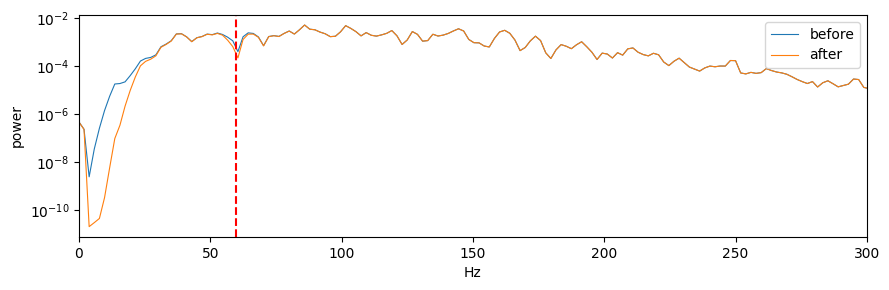

윈도우 배열 모양: (19, 300, 2)
정규화 범위: 0.0 ~ 0.9999999987119951
CWT 텐서 모양: (3, 32, 300)


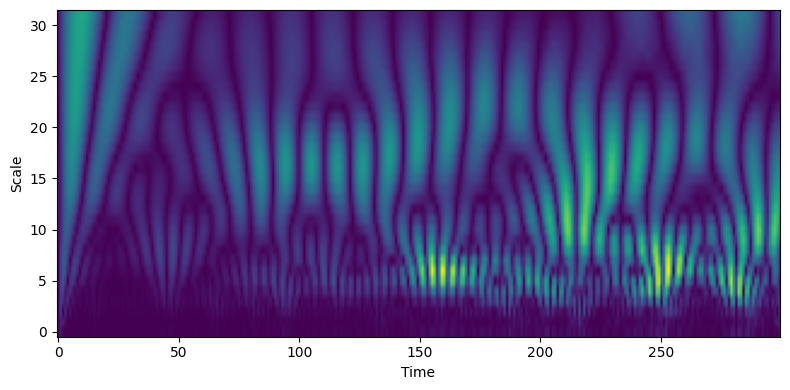

train trial: 200
test trial: 50

Train 데이터 생성 중...


KeyboardInterrupt: 

In [11]:
# ==========================================
# 2주차 실습 전체 코드
# 필터 → 윈도우 → 정규화 → CWT → 데이터셋 → DenseNet161
# ==========================================

import os
import glob
import numpy as np
import pywt
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from scipy.signal import butter, iirnotch, filtfilt, welch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161


# ==========================================
# 0. 기본 설정
# ==========================================

FS = 1000
WIN = 300
HOP = 150
SCALES = np.arange(1, 33)

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

print("사용 장치:", dev)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ==========================================
# 1. 파일 목록 + 라벨 생성
# ==========================================

files = sorted(
    glob.glob('data/**/*.csv', recursive=True)
)

labels = [
    os.path.basename(os.path.dirname(f))
    for f in files
]

print("전체 파일 수:", len(files))
print("라벨 수:", len(labels))

if len(files) == 0:
    raise ValueError("CSV 파일을 찾지 못했습니다. data 폴더 위치를 확인하세요.")


# ==========================================
# 2. CSV 불러오기
# ==========================================

def load(f):

    x = np.loadtxt(
        f,
        delimiter=',',
        skiprows=1
    )

    # (채널, 시간) → (시간, 채널)
    if x.shape[0] < x.shape[1]:
        x = x.T

    return x


def label_of(f):
    return os.path.basename(
        os.path.dirname(f)
    )


# ==========================================
# 3. 필터
# 60Hz notch + 20~499Hz band-pass
# ==========================================

def preprocess(x, fs=FS):

    # 60Hz 전원선 잡음 제거
    bn, an = iirnotch(
        60,
        30,
        fs
    )

    x = filtfilt(
        bn,
        an,
        x,
        axis=0
    )

    # 20~499Hz band-pass
    b, a = butter(
        4,
        [
            20 / (fs / 2),
            499 / (fs / 2)
        ],
        btype='band'
    )

    return filtfilt(
        b,
        a,
        x,
        axis=0
    )


# ==========================================
# 4. 필터 검증 그림
# ==========================================

x_example = load(files[0])
xf_example = preprocess(x_example)

f0, P0 = welch(
    x_example[:, 0],
    fs=FS,
    nperseg=512
)

f1, P1 = welch(
    xf_example[:, 0],
    fs=FS,
    nperseg=512
)

plt.figure(figsize=(9, 3))

plt.semilogy(
    f0,
    P0,
    label='before',
    lw=0.8
)

plt.semilogy(
    f1,
    P1,
    label='after',
    lw=0.8
)

plt.axvline(
    60,
    color='r',
    ls='--'
)

plt.xlim(0, 300)

plt.legend()
plt.xlabel('Hz')
plt.ylabel('power')

plt.tight_layout()

plt.savefig(
    'filter_check.png',
    dpi=120
)

plt.show()


# ==========================================
# 5. Sliding window
# ==========================================

def make_windows(
    x,
    win=WIN,
    hop=HOP
):

    n = (
        len(x) - win
    ) // hop + 1

    return np.stack([
        x[
            i * hop:
            i * hop + win
        ]

        for i in range(n)
    ])


# 확인
w_example = make_windows(
    xf_example
)

print(
    "윈도우 배열 모양:",
    w_example.shape
)


# ==========================================
# 6. Min-Max 정규화
# ==========================================

def minmax(
    w,
    eps=1e-8
):

    mn = w.min(
        axis=(1, 2),
        keepdims=True
    )

    mx = w.max(
        axis=(1, 2),
        keepdims=True
    )

    return (
        w - mn
    ) / (
        mx - mn + eps
    )


wn_example = minmax(
    w_example
)

print(
    "정규화 범위:",
    wn_example.min(),
    "~",
    wn_example.max()
)


# ==========================================
# 7. CWT
# (300, 2) → (3, 32, 300)
# ==========================================

def to_cwt(
    one_window,
    wavelet='morl'
):

    maps = []

    for ch in range(
        one_window.shape[1]
    ):

        coef, _ = pywt.cwt(
            one_window[:, ch],
            SCALES,
            wavelet
        )

        maps.append(
            np.abs(coef)
        )

    # 3번째 채널 = 두 채널 평균
    maps.append(
        (
            maps[0] +
            maps[1]
        ) / 2
    )

    return np.stack(
        maps
    ).astype(
        np.float32
    )


cwt_example = to_cwt(
    wn_example[0]
)

print(
    "CWT 텐서 모양:",
    cwt_example.shape
)


# CWT 예시 그림
plt.figure(
    figsize=(8, 4)
)

plt.imshow(
    cwt_example[0],
    aspect='auto',
    origin='lower'
)

plt.xlabel(
    'Time'
)

plt.ylabel(
    'Scale'
)

plt.tight_layout()

plt.savefig(
    'cwt_example.png',
    dpi=120
)

plt.show()


# ==========================================
# 8. Trial 단위 Train/Test 분할
# ==========================================

tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(
    "train trial:",
    len(tr_files)
)

print(
    "test trial:",
    len(te_files)
)


# ==========================================
# 9. 데이터셋 생성
# ==========================================

def build(flist):

    X = []
    y = []

    for f in flist:

        sig = preprocess(
            load(f)
        )

        windows = make_windows(
            sig
        )

        windows = minmax(
            windows
        )

        for w in windows:

            X.append(
                to_cwt(w)
            )

            y.append(
                label_of(f)
            )

    return (
        np.stack(X),
        np.array(y)
    )


print("\nTrain 데이터 생성 중...")

Xtr, ytr = build(
    tr_files
)

print(
    "Xtr:",
    Xtr.shape
)

print(
    "ytr:",
    ytr.shape
)


print("\nTest 데이터 생성 중...")

Xte, yte = build(
    te_files
)

print(
    "Xte:",
    Xte.shape
)

print(
    "yte:",
    yte.shape
)


# ==========================================
# 10. 중간 결과 저장
# 런타임 날아가도 다시 CWT 안 돌리게
# ==========================================

np.save(f'{SAVE_DIR}/Xtr.npy', Xtr)
np.save(f'{SAVE_DIR}/ytr.npy', ytr)
np.save(f'{SAVE_DIR}/Xte.npy', Xte)
np.save(f'{SAVE_DIR}/yte.npy', yte)

print("CWT 데이터 Drive 저장 완료")



# ==========================================
# 11. 문자열 라벨 → 숫자
# ==========================================

label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = np.array([
    label_map[y]
    for y in ytr
])

yte_num = np.array([
    label_map[y]
    for y in yte
])


# ==========================================
# 12. TensorDataset / DataLoader
# ==========================================

Xtr_tensor = torch.tensor(
    Xtr,
    dtype=torch.float32
)

ytr_tensor = torch.tensor(
    ytr_num,
    dtype=torch.long
)

Xte_tensor = torch.tensor(
    Xte,
    dtype=torch.float32
)

yte_tensor = torch.tensor(
    yte_num,
    dtype=torch.long
)


train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

test_dataset = TensorDataset(
    Xte_tensor,
    yte_tensor
)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(
    "Train batch 수:",
    len(train_loader)
)

print(
    "Test batch 수:",
    len(test_loader)
)


# ==========================================
# 13. DenseNet161
# ==========================================

model = densenet161(
    weights=None
)

model.classifier = nn.Linear(
    2208,
    5
)

model = model.to(
    dev
)

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()


# ==========================================
# 14. 학습
# 과제 제출용이면 일단 5 epoch
# ==========================================

EPOCHS = 45

for epoch in range(EPOCHS):

    model.train()

    tot = 0

    for xb, yb in train_loader:

        xb = xb.to(dev)
        yb = yb.to(dev)

        opt.zero_grad()

        output = model(xb)

        loss = crit(
            output,
            yb
        )

        loss.backward()

        opt.step()

        tot += loss.item()

    avg_loss = (
        tot /
        len(train_loader)
    )

    print(
        epoch + 1,
        avg_loss
    )


# ==========================================
# 15. 모델 저장
# ==========================================

torch.save(
    model.state_dict(),
    'densenet161_semg.pth'
)

print(
    "\n모델 저장 완료"
)

In [ ]:
torch.save({
    'epoch': 5,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': opt.state_dict()
}, f'{SAVE_DIR}/checkpoint.pth')

print("체크포인트 저장 완료")

체크포인트 저장 완료


In [ ]:
torch.save(
    model.state_dict(),
    f'{SAVE_DIR}/densenet161_semg.pth'
)

print("Drive에 모델 저장 완료")

Drive에 모델 저장 완료


In [ ]:
torch.save(
    model.state_dict(),
    f'{SAVE_DIR}/densenet161_semg.pth'
)

In [ ]:
torch.save({
    'epoch': 25,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': opt.state_dict()
}, f'{SAVE_DIR}/checkpoint_epoch25.pth')

In [ ]:
checkpoint = torch.load(
    f'{SAVE_DIR}/checkpoint_epoch25.pth',
    map_location=dev
)

model.load_state_dict(checkpoint['model_state_dict'])
opt.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch']

for epoch in range(start_epoch, 45):
    model.train()
    tot = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(dev), yb.to(dev)

        opt.zero_grad()
        output = model(xb)
        loss = crit(output, yb)

        loss.backward()
        opt.step()

        tot += loss.item()

    print(epoch + 1, tot / len(train_loader))

KeyboardInterrupt: 

In [1]:
# ==========================================
# 새 런타임에서 전체 복구
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161


# ------------------------------------------
# 1. 저장 경로
# ------------------------------------------

SAVE_DIR = '/content/drive/MyDrive/semg_project'

print("저장 폴더:", SAVE_DIR)
print("저장된 파일:", os.listdir(SAVE_DIR))


# ------------------------------------------
# 2. CWT 데이터 불러오기
# ------------------------------------------

Xtr = np.load(f'{SAVE_DIR}/Xtr.npy')
ytr = np.load(f'{SAVE_DIR}/ytr.npy')

Xte = np.load(f'{SAVE_DIR}/Xte.npy')
yte = np.load(f'{SAVE_DIR}/yte.npy')

print("Xtr:", Xtr.shape)
print("ytr:", ytr.shape)

print("Xte:", Xte.shape)
print("yte:", yte.shape)


# ------------------------------------------
# 3. 문자열 라벨 A~E → 숫자 0~4
# ------------------------------------------

label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = np.array([
    label_map[y]
    for y in ytr
])

yte_num = np.array([
    label_map[y]
    for y in yte
])


# ------------------------------------------
# 4. Tensor 변환
# ------------------------------------------

Xtr_tensor = torch.tensor(
    Xtr,
    dtype=torch.float32
)

ytr_tensor = torch.tensor(
    ytr_num,
    dtype=torch.long
)

Xte_tensor = torch.tensor(
    Xte,
    dtype=torch.float32
)

yte_tensor = torch.tensor(
    yte_num,
    dtype=torch.long
)


# ------------------------------------------
# 5. DataLoader 생성
# ------------------------------------------

train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

test_dataset = TensorDataset(
    Xte_tensor,
    yte_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batch 수:", len(train_loader))
print("Test batch 수:", len(test_loader))


# ------------------------------------------
# 6. GPU / CPU 설정
# ------------------------------------------

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

print("사용 장치:", dev)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------
# 7. DenseNet161 생성
# ------------------------------------------

model = densenet161(
    weights=None
)

model.classifier = nn.Linear(
    2208,
    5
)

model = model.to(dev)


# ------------------------------------------
# 8. 저장된 학습 가중치 불러오기
# ------------------------------------------

model_path = f'{SAVE_DIR}/densenet161_semg.pth'

model.load_state_dict(
    torch.load(
        model_path,
        map_location=dev
    )
)

print("학습된 모델 불러오기 완료")


# ------------------------------------------
# 9. optimizer / loss 함수 다시 생성
# ------------------------------------------

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()

print("전체 복구 완료")

Mounted at /content/drive
저장 폴더: /content/drive/MyDrive/semg_project
저장된 파일: ['Xtr.npy', 'ytr.npy', 'Xte.npy', 'yte.npy', 'checkpoint.pth', 'checkpoint_epoch25.pth', 'densenet161_semg.pth']
Xtr: (3800, 3, 32, 300)
ytr: (3800,)
Xte: (950, 3, 32, 300)
yte: (950,)
Train batch 수: 238
Test batch 수: 60
사용 장치: cuda
GPU: Tesla T4
학습된 모델 불러오기 완료
전체 복구 완료


In [ ]:
torch.save(
    model.state_dict(),
    f'{SAVE_DIR}/densenet161_semg.pth'
)

print("저장 완료")

저장 완료


In [ ]:
import os

print(os.path.exists(
    f'{SAVE_DIR}/densenet161_semg.pth'
))

True


In [ ]:
import pandas as pd
from collections import Counter

train_count = Counter(ytr)
test_count = Counter(yte)

df = pd.DataFrame({
    'Class': ['A', 'B', 'C', 'D', 'E'],
    'Train': [train_count[c] for c in ['A', 'B', 'C', 'D', 'E']],
    'Test': [test_count[c] for c in ['A', 'B', 'C', 'D', 'E']]
})

print("Train 샘플 수:", len(Xtr))
print("Test 샘플 수:", len(Xte))
print()
print(df.to_string(index=False))

Train 샘플 수: 3800
Test 샘플 수: 950

Class  Train  Test
    A    760   190
    B    760   190
    C    760   190
    D    760   190
    E    760   190


In [12]:
# ==========================================
# DenseNet161 처음부터 45 epoch 학습
# 이미 저장된 CWT 데이터 사용
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161


# ------------------------------------------
# 1. 기본 설정
# ------------------------------------------

SAVE_DIR = '/content/drive/MyDrive/semg_project'

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

print("사용 장치:", dev)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------
# 2. 저장된 CWT 데이터 불러오기
# ------------------------------------------

Xtr = np.load(f'{SAVE_DIR}/Xtr.npy')
ytr = np.load(f'{SAVE_DIR}/ytr.npy')

Xte = np.load(f'{SAVE_DIR}/Xte.npy')
yte = np.load(f'{SAVE_DIR}/yte.npy')

print("Xtr:", Xtr.shape)
print("Xte:", Xte.shape)


# ------------------------------------------
# 3. 문자열 라벨 → 숫자
# ------------------------------------------

label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = np.array([
    label_map[y]
    for y in ytr
])

yte_num = np.array([
    label_map[y]
    for y in yte
])


# ------------------------------------------
# 4. Tensor / DataLoader
# ------------------------------------------

Xtr_tensor = torch.tensor(
    Xtr,
    dtype=torch.float32
)

ytr_tensor = torch.tensor(
    ytr_num,
    dtype=torch.long
)

Xte_tensor = torch.tensor(
    Xte,
    dtype=torch.float32
)

yte_tensor = torch.tensor(
    yte_num,
    dtype=torch.long
)


train_dataset = TensorDataset(
    Xtr_tensor,
    ytr_tensor
)

test_dataset = TensorDataset(
    Xte_tensor,
    yte_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


# ------------------------------------------
# 5. DenseNet161 새로 생성
# 중요: 기존 25 epoch 모델 불러오지 않음
# ------------------------------------------

model = densenet161(
    weights=None
)

model.classifier = nn.Linear(
    2208,
    5
)

model = model.to(dev)


# ------------------------------------------
# 6. optimizer / loss
# ------------------------------------------

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()


# ------------------------------------------
# 7. 1 ~ 45 epoch 연속 학습
# ------------------------------------------

EPOCHS = 45

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(dev)
        yb = yb.to(dev)

        opt.zero_grad()

        output = model(xb)

        loss = crit(
            output,
            yb
        )

        loss.backward()

        opt.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"Loss: {avg_loss:.6f}"
    )


# ------------------------------------------
# 8. 최종 모델 Drive 저장
# ------------------------------------------

torch.save(
    model.state_dict(),
    f'{SAVE_DIR}/densenet161_45epoch.pth'
)

print(
    "\n45 epoch 모델 Drive 저장 완료"
)


# ------------------------------------------
# 9. checkpoint도 같이 저장
# ------------------------------------------

torch.save({
    'epoch': 45,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': opt.state_dict()
},
    f'{SAVE_DIR}/checkpoint_45epoch.pth'
)

print("checkpoint 저장 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
사용 장치: cuda
GPU: Tesla T4
Xtr: (3800, 3, 32, 300)
Xte: (950, 3, 32, 300)
Epoch 1/45 Loss: 1.023484
Epoch 2/45 Loss: 0.712560
Epoch 3/45 Loss: 0.573493
Epoch 4/45 Loss: 0.471056
Epoch 5/45 Loss: 0.448166
Epoch 6/45 Loss: 0.373607
Epoch 7/45 Loss: 0.373827
Epoch 8/45 Loss: 0.323017
Epoch 9/45 Loss: 0.316149
Epoch 10/45 Loss: 0.254389
Epoch 11/45 Loss: 0.224079
Epoch 12/45 Loss: 0.214280
Epoch 13/45 Loss: 0.213660
Epoch 14/45 Loss: 0.186786
Epoch 15/45 Loss: 0.159223
Epoch 16/45 Loss: 0.168910
Epoch 17/45 Loss: 0.143322
Epoch 18/45 Loss: 0.106802
Epoch 19/45 Loss: 0.137136
Epoch 20/45 Loss: 0.125059
Epoch 21/45 Loss: 0.106007
Epoch 22/45 Loss: 0.118523
Epoch 23/45 Loss: 0.098056
Epoch 24/45 Loss: 0.086069
Epoch 25/45 Loss: 0.057714
Epoch 26/45 Loss: 0.086636
Epoch 27/45 Loss: 0.049065
Epoch 28/45 Loss: 0.089175
Epoch 29/45 Loss: 0.103333
Epoch 30/45 Loss: 0.0946

In [13]:
model = densenet161(weights=None)
model.classifier = nn.Linear(2208, 5)
model = model.to(dev)

model.load_state_dict(
    torch.load(
        f'{SAVE_DIR}/densenet161_45epoch.pth',
        map_location=dev
    )
)

<All keys matched successfully>

In [14]:
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

preds = []
trues = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(dev)

        out = model(xb)

        preds += out.argmax(1).cpu().tolist()
        trues += yb.tolist()


acc = accuracy_score(
    trues,
    preds
)

f1 = f1_score(
    trues,
    preds,
    average='macro'
)

print(
    f'accuracy {acc:.4f} '
    f'macro F1 {f1:.4f}'
)

print(
    classification_report(
        trues,
        preds,
        digits=3
    )
)

cm = confusion_matrix(
    trues,
    preds
)

print(cm)

accuracy 0.8937 macro F1 0.8927
              precision    recall  f1-score   support

           0      0.969     1.000     0.984       190
           1      0.907     0.768     0.832       190
           2      0.933     0.879     0.905       190
           3      0.827     0.958     0.888       190
           4      0.845     0.863     0.854       190

    accuracy                          0.894       950
   macro avg      0.896     0.894     0.893       950
weighted avg      0.896     0.894     0.893       950

[[190   0   0   0   0]
 [  5 146   6   9  24]
 [  0   0 167  19   4]
 [  0   3   3 182   2]
 [  1  12   3  10 164]]


In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(5, shuffle=True, random_state=42)
scores = []
# 주의: 시행(파일) 단위로나눈다
for tr_i, va_i in skf.split(files, labels):
Xtr, ytr = build([files[i] for i in tr_i])
Xva, yva = build([files[i] for i in va_i])
m = fresh_model() # 매번새로
acc = train_and_eval(m, Xtr, ytr, Xva, yva)
scores.append(acc)
print(f'fold {len(scores)}: {acc:.4f}')
print(f'평균{np.mean(scores)*100:.2f}'
f' ±{np.std(scores)*100:.2f} %')

In [17]:
# ==========================================
# 5-Fold Cross Validation
# fold별 결과 + 모델을 Google Drive에 저장
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import torch

from sklearn.model_selection import StratifiedKFold


# ------------------------------------------
# 1. 저장 경로
# ------------------------------------------

SAVE_DIR = '/content/drive/MyDrive/semg_project'
CV_DIR = f'{SAVE_DIR}/5fold'

os.makedirs(CV_DIR, exist_ok=True)

print("5-fold 저장 경로:", CV_DIR)


# ------------------------------------------
# 2. 5-fold 설정
# ------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []


# ------------------------------------------
# 3. 5-fold 실행
# ------------------------------------------

for fold, (tr_i, va_i) in enumerate(
    skf.split(files, labels),
    start=1
):

    print("\n" + "=" * 50)
    print(f"Fold {fold}/5 시작")
    print("=" * 50)


    # --------------------------------------
    # 파일 단위 Train / Validation 분할
    # --------------------------------------

    train_files = [
        files[i]
        for i in tr_i
    ]

    val_files = [
        files[i]
        for i in va_i
    ]


    # --------------------------------------
    # CWT 데이터 생성
    # --------------------------------------

    print("Train 데이터 생성 중...")

    Xtr_fold, ytr_fold = build(
        train_files
    )

    print("Validation 데이터 생성 중...")

    Xva_fold, yva_fold = build(
        val_files
    )

    print(
        "Train:",
        Xtr_fold.shape
    )

    print(
        "Validation:",
        Xva_fold.shape
    )


    # --------------------------------------
    # 매 fold마다 새 모델
    # --------------------------------------

    m = fresh_model()


    # --------------------------------------
    # 학습 + 평가
    # --------------------------------------

    acc = train_and_eval(
        m,
        Xtr_fold,
        ytr_fold,
        Xva_fold,
        yva_fold
    )

    scores.append(
        float(acc)
    )


    # --------------------------------------
    # Fold 모델 저장
    # --------------------------------------

    torch.save(
        m.state_dict(),
        f'{CV_DIR}/fold_{fold}_model.pth'
    )


    # --------------------------------------
    # 지금까지의 score 즉시 저장
    # 런타임 끊겨도 결과 보존
    # --------------------------------------

    np.save(
        f'{CV_DIR}/scores.npy',
        np.array(scores)
    )


    # JSON으로도 저장
    fold_result = {
        'completed_folds': fold,
        'scores': scores,
        'current_mean': float(
            np.mean(scores)
        ),
        'current_std': float(
            np.std(scores)
        )
    }

    with open(
        f'{CV_DIR}/progress.json',
        'w',
        encoding='utf-8'
    ) as f:

        json.dump(
            fold_result,
            f,
            indent=4
        )


    print(
        f'Fold {fold} accuracy: '
        f'{acc:.4f}'
    )

    print("Drive 저장 완료")


# ==========================================
# 4. 최종 결과
# ==========================================

mean_acc = np.mean(scores)
std_acc = np.std(scores)

print("\n" + "=" * 50)
print("5-Fold Cross Validation 완료")
print("=" * 50)

for i, score in enumerate(
    scores,
    start=1
):
    print(
        f'Fold {i}: '
        f'{score * 100:.2f}%'
    )

print(
    f'\n평균: '
    f'{mean_acc * 100:.2f}'
    f' ± '
    f'{std_acc * 100:.2f}%'
)


# ------------------------------------------
# 5. 최종 요약 파일 저장
# ------------------------------------------

final_result = {
    'fold_scores': scores,
    'mean_accuracy': float(mean_acc),
    'std_accuracy': float(std_acc),
    'mean_accuracy_percent': float(
        mean_acc * 100
    ),
    'std_accuracy_percent': float(
        std_acc * 100
    )
}

with open(
    f'{CV_DIR}/final_result.json',
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )

print(
    "\n최종 결과 저장 완료:",
    f'{CV_DIR}/final_result.json'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
5-fold 저장 경로: /content/drive/MyDrive/semg_project/5fold

Fold 1/5 시작
Train 데이터 생성 중...
Validation 데이터 생성 중...
Train: (3800, 3, 32, 300)
Validation: (950, 3, 32, 300)
Fold 1 accuracy: 0.8747
Drive 저장 완료

Fold 2/5 시작
Train 데이터 생성 중...
Validation 데이터 생성 중...
Train: (3800, 3, 32, 300)
Validation: (950, 3, 32, 300)
Fold 2 accuracy: 0.8905
Drive 저장 완료

Fold 3/5 시작
Train 데이터 생성 중...
Validation 데이터 생성 중...
Train: (3800, 3, 32, 300)
Validation: (950, 3, 32, 300)
Fold 3 accuracy: 0.8716
Drive 저장 완료

Fold 4/5 시작
Train 데이터 생성 중...
Validation 데이터 생성 중...
Train: (3800, 3, 32, 300)
Validation: (950, 3, 32, 300)
Fold 4 accuracy: 0.8832
Drive 저장 완료

Fold 5/5 시작
Train 데이터 생성 중...
Validation 데이터 생성 중...
Train: (3800, 3, 32, 300)
Validation: (950, 3, 32, 300)
Fold 5 accuracy: 0.8937
Drive 저장 완료

5-Fold Cross Validation 완료
Fold 1: 87.47%
Fold 2: 89.05%
Fold 3: 87.16%
Fold 4: 88.3

In [16]:
def fresh_model():
    m = densenet161(weights=None)
    m.classifier = nn.Linear(2208, 5)
    return m.to(dev)


def train_and_eval(m, Xtr, ytr, Xva, yva):
    label_map = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4}

    ytr_num = np.array([label_map[y] for y in ytr])
    yva_num = np.array([label_map[y] for y in yva])

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(Xtr, dtype=torch.float32),
            torch.tensor(ytr_num, dtype=torch.long)
        ),
        batch_size=16,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(Xva, dtype=torch.float32),
            torch.tensor(yva_num, dtype=torch.long)
        ),
        batch_size=16,
        shuffle=False
    )

    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    for epoch in range(45):
        m.train()

        for xb, yb in train_loader:
            xb = xb.to(dev)
            yb = yb.to(dev)

            opt.zero_grad()

            out = m(xb)
            loss = crit(out, yb)

            loss.backward()
            opt.step()

    m.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(dev)
            yb = yb.to(dev)

            out = m(xb)
            pred = out.argmax(1)

            correct += (pred == yb).sum().item()
            total += yb.size(0)

    return correct / total

In [20]:
# ==========================================
# 2D CNN + ResNet18 베이스라인 비교
# 같은 Xtr/Xte 사용
# 45 epoch / batch 16 / Adam lr=1e-3
# ==========================================

import time
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ------------------------------------------
# 1. 문자열 라벨 -> 숫자
# ------------------------------------------

label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = np.array([label_map[y] for y in ytr])
yte_num = np.array([label_map[y] for y in yte])


# ------------------------------------------
# 2. DataLoader
# ------------------------------------------

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(Xtr, dtype=torch.float32),
        torch.tensor(ytr_num, dtype=torch.long)
    ),
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(Xte, dtype=torch.float32),
        torch.tensor(yte_num, dtype=torch.long)
    ),
    batch_size=16,
    shuffle=False
)


# ------------------------------------------
# 3. 모델 생성 함수
# ------------------------------------------

def make_2dcnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),

        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(64, 5)
    ).to(dev)


def make_resnet18():
    m = resnet18(weights=None)
    m.fc = nn.Linear(512, 5)
    return m.to(dev)


# ------------------------------------------
# 4. 학습 + 평가 함수
# ------------------------------------------

def train_and_evaluate(model, name):

    opt = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    crit = nn.CrossEntropyLoss()

    start_time = time.time()

    # 45 epoch 학습
    for epoch in range(45):

        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:

            xb = xb.to(dev)
            yb = yb.to(dev)

            opt.zero_grad()

            out = model(xb)

            loss = crit(out, yb)

            loss.backward()
            opt.step()

            total_loss += loss.item()

        print(
            f'{name} '
            f'Epoch {epoch+1}/45 '
            f'Loss: {total_loss/len(train_loader):.6f}'
        )


    train_time = time.time() - start_time


    # --------------------------------------
    # 테스트 평가
    # --------------------------------------

    model.eval()

    preds = []
    trues = []

    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(dev)

            out = model(xb)

            pred = out.argmax(1).cpu().numpy()

            preds.extend(pred)
            trues.extend(yb.numpy())


    acc = accuracy_score(
        trues,
        preds
    )

    precision = precision_score(
        trues,
        preds,
        average='macro'
    )

    recall = recall_score(
        trues,
        preds,
        average='macro'
    )

    f1 = f1_score(
        trues,
        preds,
        average='macro'
    )

    cm = confusion_matrix(
        trues,
        preds
    )

    params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


    print("\n==============================")
    print(name)
    print("==============================")
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1       : {f1:.4f}')
    print(f'Train time: {train_time:.1f} sec')
    print(f'Parameters: {params:,}')
    print("\nConfusion Matrix")
    print(cm)
    print()


    return {
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Train Time': train_time,
        'Parameters': params,
        'CM': cm
    }


# ==========================================
# 5. 2D CNN 학습
# ==========================================

cnn_model = make_2dcnn()

cnn_result = train_and_evaluate(
    cnn_model,
    '2D CNN'
)


# ==========================================
# 6. ResNet18 학습
# ==========================================

resnet_model = make_resnet18()

resnet_result = train_and_evaluate(
    resnet_model,
    'ResNet18'
)


# ==========================================
# 7. 결과 요약
# ==========================================

print("\n========== 최종 비교 ==========")

print(
    "DenseNet161:",
    "Accuracy=0.8937",
    "F1=0.8927"
)

print(
    "2D CNN:",
    f"Accuracy={cnn_result['Accuracy']:.4f}",
    f"F1={cnn_result['F1']:.4f}"
)

print(
    "ResNet18:",
    f"Accuracy={resnet_result['Accuracy']:.4f}",
    f"F1={resnet_result['F1']:.4f}"
)

2D CNN Epoch 1/45 Loss: 1.379080
2D CNN Epoch 2/45 Loss: 1.122927
2D CNN Epoch 3/45 Loss: 1.069634
2D CNN Epoch 4/45 Loss: 1.049785
2D CNN Epoch 5/45 Loss: 1.037402
2D CNN Epoch 6/45 Loss: 1.030360
2D CNN Epoch 7/45 Loss: 1.023069
2D CNN Epoch 8/45 Loss: 1.016804
2D CNN Epoch 9/45 Loss: 1.007021
2D CNN Epoch 10/45 Loss: 1.005249
2D CNN Epoch 11/45 Loss: 1.000020
2D CNN Epoch 12/45 Loss: 0.987964
2D CNN Epoch 13/45 Loss: 0.984755
2D CNN Epoch 14/45 Loss: 0.977328
2D CNN Epoch 15/45 Loss: 0.972322
2D CNN Epoch 16/45 Loss: 0.963097
2D CNN Epoch 17/45 Loss: 0.960741
2D CNN Epoch 18/45 Loss: 0.963367
2D CNN Epoch 19/45 Loss: 0.955142
2D CNN Epoch 20/45 Loss: 0.948558
2D CNN Epoch 21/45 Loss: 0.944657
2D CNN Epoch 22/45 Loss: 0.943655
2D CNN Epoch 23/45 Loss: 0.934934
2D CNN Epoch 24/45 Loss: 0.942972
2D CNN Epoch 25/45 Loss: 0.926245
2D CNN Epoch 26/45 Loss: 0.928156
2D CNN Epoch 27/45 Loss: 0.922206
2D CNN Epoch 28/45 Loss: 0.921667
2D CNN Epoch 29/45 Loss: 0.914696
2D CNN Epoch 30/45 Loss

In [21]:
# ==========================================
# DenseNet161 Run2 + Run3 자동 학습
# 각 run 45 epoch
# 평가 + 저장 + 최종 3회 평균
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import time
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ==========================================
# 1. 기본 설정
# ==========================================

SAVE_DIR = '/content/drive/MyDrive/semg_project'
os.makedirs(SAVE_DIR, exist_ok=True)

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

print("사용 장치:", dev)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ==========================================
# 2. 저장된 CWT 데이터 불러오기
# ==========================================

Xtr = np.load(f'{SAVE_DIR}/Xtr.npy')
ytr = np.load(f'{SAVE_DIR}/ytr.npy')

Xte = np.load(f'{SAVE_DIR}/Xte.npy')
yte = np.load(f'{SAVE_DIR}/yte.npy')

print("Xtr:", Xtr.shape)
print("Xte:", Xte.shape)


# ==========================================
# 3. 문자열 라벨 -> 숫자
# ==========================================

label_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4
}

ytr_num = np.array([
    label_map[y]
    for y in ytr
])

yte_num = np.array([
    label_map[y]
    for y in yte
])


# ==========================================
# 4. Tensor / DataLoader
# ==========================================

train_dataset = TensorDataset(
    torch.tensor(Xtr, dtype=torch.float32),
    torch.tensor(ytr_num, dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(Xte, dtype=torch.float32),
    torch.tensor(yte_num, dtype=torch.long)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


# ==========================================
# 5. DenseNet 생성 함수
# 매 run마다 새 모델 생성
# ==========================================

def make_densenet():

    model = densenet161(
        weights=None
    )

    model.classifier = nn.Linear(
        2208,
        5
    )

    return model.to(dev)


# ==========================================
# 6. 학습 + 평가 함수
# ==========================================

def train_and_evaluate(run_num):

    print("\n")
    print("=" * 60)
    print(f"DenseNet161 Run {run_num} 시작")
    print("=" * 60)

    # -------------------------
    # 새 모델 생성
    # -------------------------

    model = make_densenet()

    opt = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    crit = nn.CrossEntropyLoss()


    # -------------------------
    # 45 epoch 학습
    # -------------------------

    start_time = time.time()

    EPOCHS = 45

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0.0

        for xb, yb in train_loader:

            xb = xb.to(dev)
            yb = yb.to(dev)

            opt.zero_grad()

            output = model(xb)

            loss = crit(
                output,
                yb
            )

            loss.backward()

            opt.step()

            total_loss += loss.item()


        avg_loss = (
            total_loss /
            len(train_loader)
        )

        print(
            f"Run {run_num} "
            f"Epoch {epoch + 1}/{EPOCHS} "
            f"Loss: {avg_loss:.6f}"
        )


    train_time = time.time() - start_time


    # ======================================
    # 7. 모델 저장
    # ======================================

    model_path = (
        f'{SAVE_DIR}/'
        f'densenet161_run{run_num}_45epoch.pth'
    )

    torch.save(
        model.state_dict(),
        model_path
    )


    checkpoint_path = (
        f'{SAVE_DIR}/'
        f'checkpoint_run{run_num}_45epoch.pth'
    )

    torch.save({
        'epoch': 45,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': opt.state_dict()
    },
        checkpoint_path
    )

    print(
        f"\nRun {run_num} 모델 저장 완료"
    )


    # ======================================
    # 8. 테스트 평가
    # ======================================

    model.eval()

    preds = []
    trues = []

    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(dev)

            output = model(xb)

            pred = (
                output.argmax(1)
                .cpu()
                .numpy()
            )

            preds.extend(pred)
            trues.extend(yb.numpy())


    # ======================================
    # 9. 평가 지표
    # ======================================

    acc = accuracy_score(
        trues,
        preds
    )

    precision = precision_score(
        trues,
        preds,
        average='macro'
    )

    recall = recall_score(
        trues,
        preds,
        average='macro'
    )

    f1 = f1_score(
        trues,
        preds,
        average='macro'
    )

    cm = confusion_matrix(
        trues,
        preds
    )


    print("\n")
    print("=" * 40)
    print(f"DenseNet161 Run {run_num} 결과")
    print("=" * 40)

    print(
        f"Accuracy : {acc:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    print(
        f"Train time: {train_time:.1f} sec"
    )

    print("\nConfusion Matrix")

    print(cm)


    return {
        'run': run_num,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Train Time': train_time,
        'CM': cm
    }


# ==========================================
# 10. 기존 Run1 결과
# ==========================================

run1 = {
    'run': 1,
    'Accuracy': 0.8937,
    'Precision': 0.8960,
    'Recall': 0.8940,
    'F1': 0.8927
}


# ==========================================
# 11. Run2 / Run3 자동 실행
# ==========================================

run2 = train_and_evaluate(2)

run3 = train_and_evaluate(3)


# ==========================================
# 12. 3회 결과 정리
# ==========================================

all_runs = [
    run1,
    run2,
    run3
]


accs = [
    r['Accuracy']
    for r in all_runs
]

precisions = [
    r['Precision']
    for r in all_runs
]

recalls = [
    r['Recall']
    for r in all_runs
]

f1s = [
    r['F1']
    for r in all_runs
]


# ==========================================
# 13. 최종 출력
# ==========================================

print("\n")
print("=" * 60)
print("DenseNet161 3회 실행 최종 결과")
print("=" * 60)

for r in all_runs:

    print(
        f"Run {r['run']}: "
        f"Accuracy={r['Accuracy']:.4f}, "
        f"Precision={r['Precision']:.4f}, "
        f"Recall={r['Recall']:.4f}, "
        f"F1={r['F1']:.4f}"
    )


print("\n------------------------------")

print(
    f"Accuracy 평균: "
    f"{np.mean(accs):.4f}"
)

print(
    f"Accuracy 표준편차: "
    f"{np.std(accs):.4f}"
)

print(
    f"Precision 평균: "
    f"{np.mean(precisions):.4f}"
)

print(
    f"Recall 평균: "
    f"{np.mean(recalls):.4f}"
)

print(
    f"F1 평균: "
    f"{np.mean(f1s):.4f}"
)

print("------------------------------")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
사용 장치: cuda
GPU: Tesla T4
Xtr: (3800, 3, 32, 300)
Xte: (950, 3, 32, 300)


DenseNet161 Run 2 시작
Run 2 Epoch 1/45 Loss: 1.021828
Run 2 Epoch 2/45 Loss: 0.740615
Run 2 Epoch 3/45 Loss: 0.600620
Run 2 Epoch 4/45 Loss: 0.513501
Run 2 Epoch 5/45 Loss: 0.443008
Run 2 Epoch 6/45 Loss: 0.402671
Run 2 Epoch 7/45 Loss: 0.367089
Run 2 Epoch 8/45 Loss: 0.325810
Run 2 Epoch 9/45 Loss: 0.291437
Run 2 Epoch 10/45 Loss: 0.276940
Run 2 Epoch 11/45 Loss: 0.257961
Run 2 Epoch 12/45 Loss: 0.239831
Run 2 Epoch 13/45 Loss: 0.209466
Run 2 Epoch 14/45 Loss: 0.194169
Run 2 Epoch 15/45 Loss: 0.190560
Run 2 Epoch 16/45 Loss: 0.183019
Run 2 Epoch 17/45 Loss: 0.164890
Run 2 Epoch 18/45 Loss: 0.149720
Run 2 Epoch 19/45 Loss: 0.132325
Run 2 Epoch 20/45 Loss: 0.150098
Run 2 Epoch 21/45 Loss: 0.127964
Run 2 Epoch 22/45 Loss: 0.108457
Run 2 Epoch 23/45 Loss: 0.130849
Run 2 Epoch 24/45 Loss: 0

In [23]:
import time
import torch

# ==========================================
# 계산 비용 측정
# ==========================================

# 1. 파라미터 수
n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("파라미터 수:", f"{n_params:,}")


# 2. 샘플 1개 준비
model.eval()

xb = next(iter(test_loader))[0][:1].to(dev)


# 3. GPU 예열
with torch.no_grad():

    for _ in range(10):
        model(xb)

if dev == 'cuda':
    torch.cuda.synchronize()


# 4. 추론시간 측정
start = time.time()

with torch.no_grad():

    for _ in range(100):
        model(xb)

if dev == 'cuda':
    torch.cuda.synchronize()

elapsed = time.time() - start


# 100회 평균 -> 1회당 ms
inference_ms = (
    elapsed / 100
) * 1000


print(
    f"샘플당 추론시간: "
    f"{inference_ms:.3f} ms"
)

파라미터 수: 26,483,045
샘플당 추론시간: 78.560 ms


In [27]:
import time
import numpy as np
import torch

def measure_inference_time(model, name, repeats=5):
    model.eval()

    xb = next(iter(test_loader))[0][:1].to(dev)

    # 예열
    with torch.no_grad():
        for _ in range(20):
            model(xb)

    if dev == 'cuda':
        torch.cuda.synchronize()

    times = []

    for _ in range(repeats):

        if dev == 'cuda':
            torch.cuda.synchronize()

        t0 = time.perf_counter()

        with torch.no_grad():
            for _ in range(100):
                model(xb)

        if dev == 'cuda':
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - t0

        # 1회 추론당 ms
        times.append(
            elapsed / 100 * 1000
        )

    mean_time = np.mean(times)
    std_time = np.std(times)

    print(
        f'{name}: '
        f'{mean_time:.3f} ± {std_time:.3f} ms'
    )

    print(
        '각 측정:',
        [round(x, 3) for x in times]
    )

    return mean_time

In [28]:
cnn_time = measure_inference_time(
    cnn_model,
    '2D CNN'
)

resnet_time = measure_inference_time(
    resnet_model,
    'ResNet18'
)

dense_time = measure_inference_time(
    model,
    'DenseNet161'
)

2D CNN: 0.768 ± 0.139 ms
각 측정: [0.746, 0.951, 0.881, 0.551, 0.712]
ResNet18: 8.679 ± 2.526 ms
각 측정: [8.222, 12.274, 10.827, 6.352, 5.721]
DenseNet161: 56.980 ± 19.329 ms
각 측정: [55.822, 80.478, 53.994, 70.948, 23.656]


In [29]:
import numpy as np
import torch

def measure_inference_cuda(model, name, repeats=20):
    model.eval()
    xb = next(iter(test_loader))[0][:1].to(dev)

    # warm-up
    with torch.no_grad():
        for _ in range(30):
            model(xb)

    torch.cuda.synchronize()

    times = []

    for _ in range(repeats):
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)

        starter.record()

        with torch.no_grad():
            for _ in range(100):
                model(xb)

        ender.record()

        torch.cuda.synchronize()

        total_ms = starter.elapsed_time(ender)

        # 100회 평균
        times.append(total_ms / 100)

    mean_time = np.mean(times)
    std_time = np.std(times)
    median_time = np.median(times)

    print(f'{name}')
    print(f'평균: {mean_time:.3f} ± {std_time:.3f} ms')
    print(f'중앙값: {median_time:.3f} ms')

    return mean_time

In [30]:
measure_inference_cuda(cnn_model, '2D CNN')
measure_inference_cuda(resnet_model, 'ResNet18')
measure_inference_cuda(model, 'DenseNet161')

2D CNN
평균: 0.545 ± 0.054 ms
중앙값: 0.525 ms
ResNet18
평균: 5.099 ± 0.828 ms
중앙값: 4.728 ms
DenseNet161
평균: 22.882 ± 4.591 ms
중앙값: 19.843 ms


np.float64(22.881892822265627)

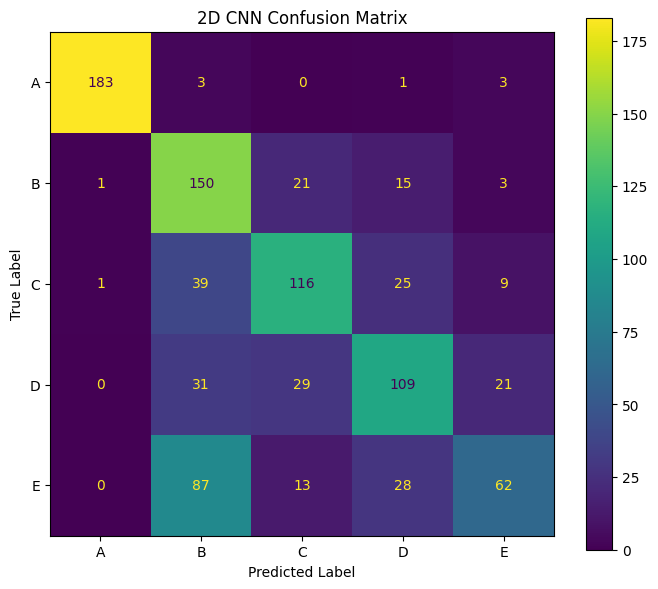

저장 완료: /content/drive/MyDrive/semg_project/results/confusion_2dcnn.png


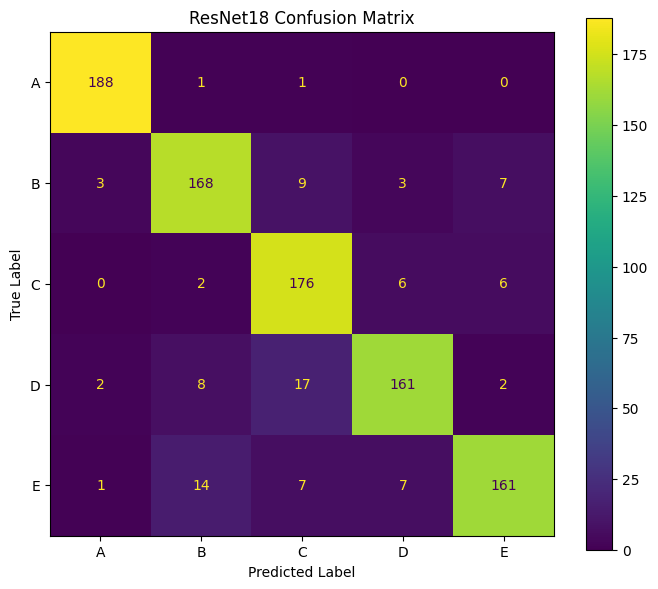

저장 완료: /content/drive/MyDrive/semg_project/results/confusion_resnet18.png


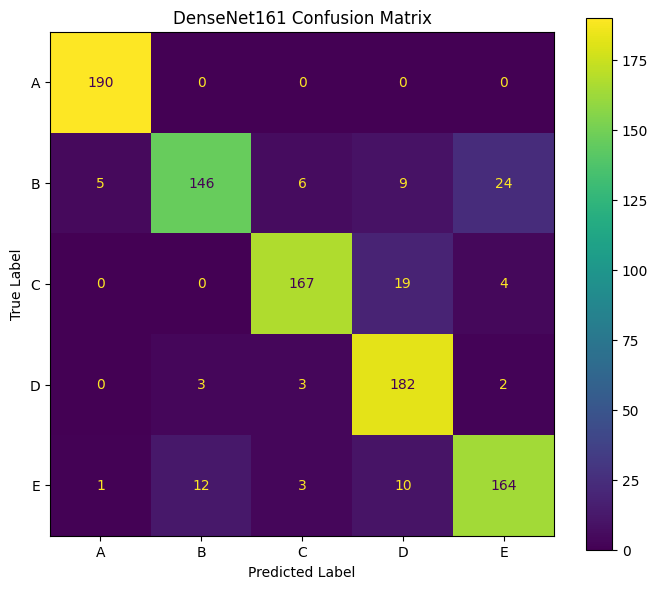

저장 완료: /content/drive/MyDrive/semg_project/results/confusion_densenet.png


In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 저장 폴더
RESULT_DIR = '/content/drive/MyDrive/semg_project/results'
os.makedirs(RESULT_DIR, exist_ok=True)

classes = ['A', 'B', 'C', 'D', 'E']

# ------------------------------------------
# Confusion Matrix 값
# ------------------------------------------

cm_2dcnn = np.array([
    [183,  3,  0,  1,  3],
    [  1,150, 21, 15,  3],
    [  1, 39,116, 25,  9],
    [  0, 31, 29,109, 21],
    [  0, 87, 13, 28, 62]
])

cm_resnet18 = np.array([
    [188,  1,  1,  0,  0],
    [  3,168,  9,  3,  7],
    [  0,  2,176,  6,  6],
    [  2,  8, 17,161,  2],
    [  1, 14,  7,  7,161]
])

cm_densenet161 = np.array([
    [190,  0,  0,  0,  0],
    [  5,146,  6,  9, 24],
    [  0,  0,167, 19,  4],
    [  0,  3,  3,182,  2],
    [  1, 12,  3, 10,164]
])

# ------------------------------------------
# 저장 함수
# ------------------------------------------

def save_confusion_matrix(cm, title, filename):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    disp.plot(
        ax=ax,
        values_format='d',
        colorbar=True
    )

    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    plt.tight_layout()

    save_path = os.path.join(
        RESULT_DIR,
        filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

    print("저장 완료:", save_path)


# ------------------------------------------
# 3개 저장
# ------------------------------------------

save_confusion_matrix(
    cm_2dcnn,
    '2D CNN Confusion Matrix',
    'confusion_2dcnn.png'
)

save_confusion_matrix(
    cm_resnet18,
    'ResNet18 Confusion Matrix',
    'confusion_resnet18.png'
)

save_confusion_matrix(
    cm_densenet161,
    'DenseNet161 Confusion Matrix',
    'confusion_densenet.png'
)

In [33]:
%ls

cwt_example.png  data/  drive/  filter_check.png  sample_data/  semg-auth/
